# Import Libraries

In [1]:
%matplotlib ipympl
from time import time
import scipy.cluster.hierarchy as spc
from pennylane import numpy as pnp
import pennylane as qml
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
# set style matplotlib
sns.set_style("whitegrid")
import Preprocessing_module
from sklearn.preprocessing import MinMaxScaler

C:\Users\mathi\AppData\Local\Temp\ipykernel_26256\1601743440.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.4)
  import scipy.cluster.hierarchy as spc


# DF Parameters

In [18]:
data = [
    ["Temperatura całkowita na wlocie wentylatora", 
     "T2", "°R"],
    ["Temperatura całkowita na wylocie Sprężarki Niskiego Ciśnienia", 
     "T24", "°R"],
    ["Temperatura całkowita na wylocie Sprężarki Wysokiego Ciśnienia", 
     "T30", "°R"],
    ["Temperatura całkowita na wylocie Turbiny Niskiego Ciśnienia", 
     "T50", "°R"],
    ["Ciśnienie na wlocie wentylatora", 
     "P2", "psia"],
    ["Ciśnienie całkowite w kanale zewnętrznym", 
     "P15", "psia"],
    ["Ciśnienie całkowite na wylocie Sprężarki Wysokiego Ciśnienia", 
     "P30", "psia"],
    ["Prędkość obrotowa wentylatora", 
     "Nf", "obr/min"],
    ["Prędkość obrotowa wytwornicy spalin", 
     "Nc", "obr/min"],
    ["Spręż silnika", 
     "epr", "--"],
    ["Ciśnienie statyczne na wylocie Sprężarki Wysokiego Ciśnienia", 
     "Ps30", "psia"],
    ["Stosunek wydatku paliwa do ciśnienia statycznego na wylocie Sprężarki Wysokiego Ciśnienia", 
     "phi", "pps/psi"],
    [ "Poprawiona prędkość obrotowa wentylatora", 
     "NRf", "obr/min"],
    [ "Poprawiona prędkość obrotowa wytwornicy spalin", 
     "NRc", "obr/min"],
    [ "Stosunek dwuprzepływowości", 
     "BPR", "--"],
    [ "Stosunek wydatku paliwa do powietrza", 
     "farB", "--"],
    [ "Entalpia wydatku masowego", 
     "htBleed", "--"],
    [ "Wymagana prędkość obrotowa wentylatora", 
     "Nf_dmd", "obr/min"],
    [ "Wymagana poprawiona prędkość obrotowa wentylatora", 
     "PCNfR_dmd", "obr/min"],
    [ "Wydatek masowy chłodzenia Turbiny Wysokiego Ciśnienia", 
     "W31", "lbm/s"],
    [ "Wydatek masowy chłodzenia Turbiny Niskiego Ciśnienia", 
     "W32", "lbm/s"],
]

columns = ["Nazwa", "Oznaczenie", "Jednostka"]

df_params = pd.DataFrame(data, columns=columns)
df_params


,Nazwa,Oznaczenie,Jednostka
0,Temperatura całkowita na wlocie wentylatora,T2,°R
1,Temperatura całkowita na wylocie Sprężarki Nis...,T24,°R
2,Temperatura całkowita na wylocie Sprężarki Wys...,T30,°R
3,Temperatura całkowita na wylocie Turbiny Niski...,T50,°R
4,Ciśnienie na wlocie wentylatora,P2,psia
5,Ciśnienie całkowite w kanale zewnętrznym,P15,psia
6,Ciśnienie całkowite na wylocie Sprężarki Wysok...,P30,psia
7,Prędkość obrotowa wentylatora,Nf,obr/min
8,Prędkość obrotowa wytwornicy spalin,Nc,obr/min
9,Spręż silnika,epr,--


# Data Import

In [2]:
filepath = r'C:\Users\mathi\OneDrive\Documents\Studia\SGH\Semestr 4\Praca dyplomowa'
df, df_scaled = Preprocessing_module.read_data(file_path=f'{filepath}/CMAPSSData/train_FD001.txt')


Deleted column: Operational setting 3
Deleted column: T2
Deleted column: P2
Deleted column: epr
Deleted column: farB
Deleted column: Nf_dmd
Deleted column: PCNfR_dmd


In [3]:
df.head()

,ESN,Cycles,Operational setting 1,Operational setting 2,T24,T30,T50,P15,P30,Nf,...,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,Max Life,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,187


# Correlation Analysis

Selected features: {2: ['Operational setting 1'], 3: ['Operational setting 2'], 4: ['T24', 'T30', 'T50', 'Nf', 'Ps30', 'NRf', 'BPR', 'htBleed'], 5: ['P15'], 1: ['P30', 'phi', 'W31', 'W32', 'RUL'], 6: ['Nc', 'NRc']}


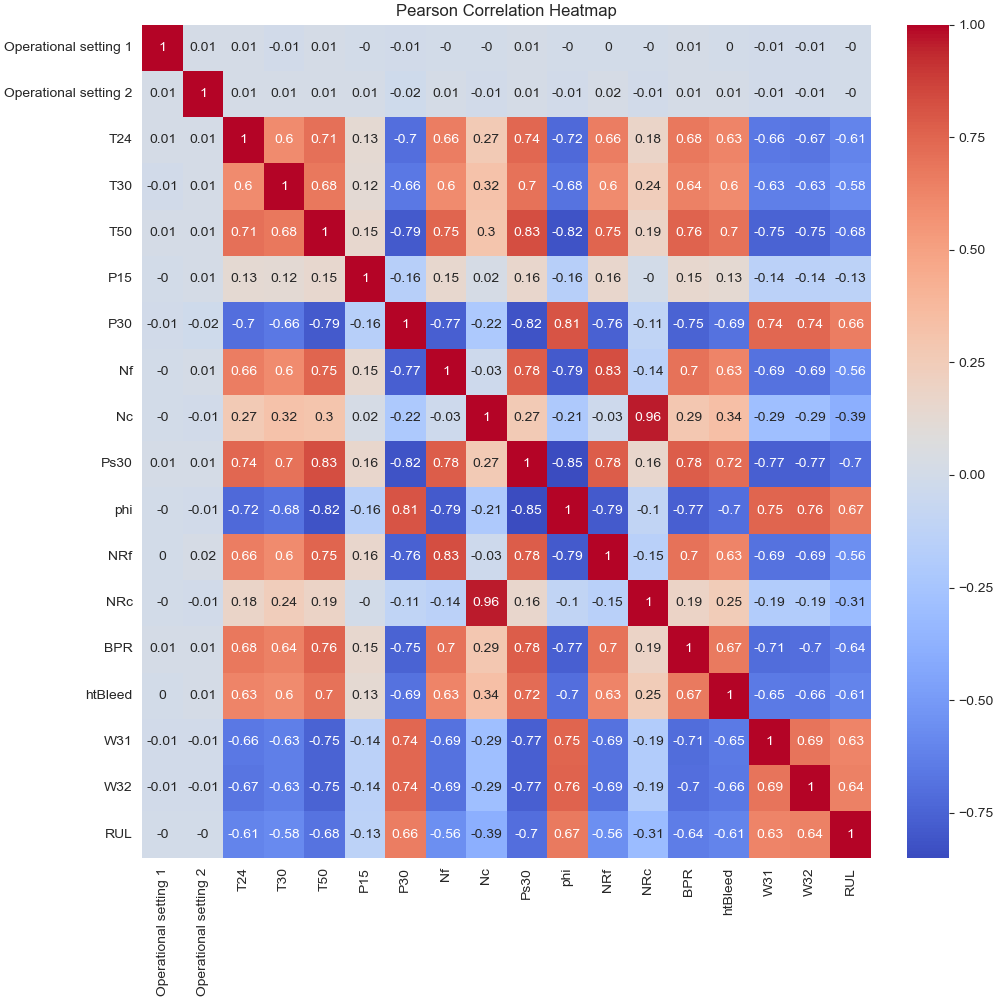

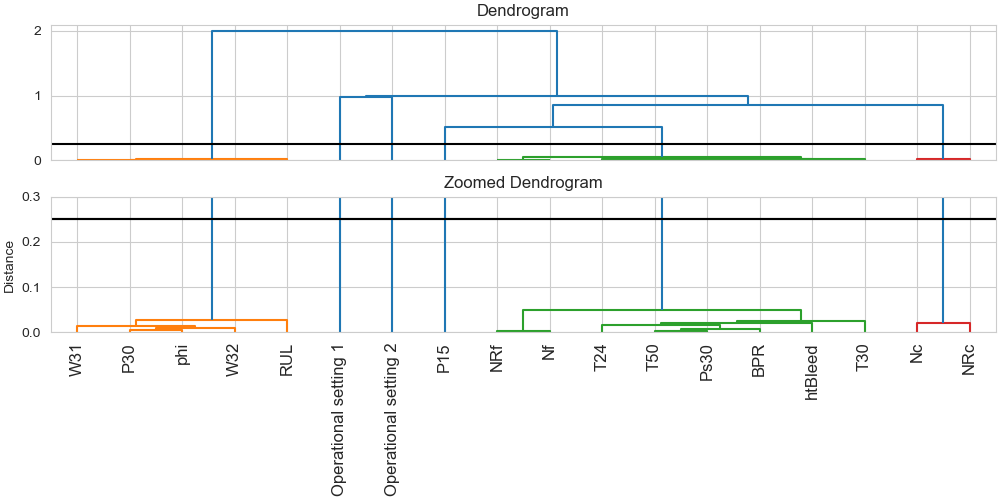

In [5]:
max_distance = 0.25
pearson, linkage_corr =  Preprocessing_module.correlation_analysis(df,
                                                 output_path=f'{filepath}/Output',
                                                 max_distance=max_distance)
selected_features,clusters = Preprocessing_module.clusters(
        pearson, linkage_corr, max_distance=max_distance)
print("Selected features:", clusters)

In [20]:
clusters

{2: ['Operational setting 1'],
 3: ['Operational setting 2'],
 4: ['T24', 'T30', 'T50', 'Nf', 'Ps30', 'NRf', 'BPR', 'htBleed'],
 5: ['P15'],
 1: ['P30', 'phi', 'W31', 'W32', 'RUL'],
 6: ['Nc', 'NRc']}

In [38]:
clusters_df = (
    pd.Series(clusters)
      .explode()
      .rename("Feature")
      .reset_index()
      .set_index(["index", "Feature"])
)

clusters_df.index.names = ["Grupa", "Symbol"]

clusters_df['Opis']=None
for index, row in clusters_df.iterrows():
    opis = df_params.loc[df_params['Oznaczenie'] == index[1], 'Nazwa']
    if not opis.empty:
        clusters_df.at[index, 'Opis'] = opis.iloc[0]

# Sortowanie po grupie, a następnie po symbolu
clusters_df = clusters_df.sort_index(level=["Grupa", "Symbol"])

print(clusters_df.to_latex())
clusters_df

\begin{tabular}{lll}
\toprule
 &  & Opis \\
Grupa & Symbol &  \\
\midrule
\multirow[t]{5}{*}{1} & P30 & Ciśnienie całkowite na wylocie Sprężarki Wysokiego Ciśnienia \\
 & RUL & NaN \\
 & W31 & Wydatek masowy chłodzenia Turbiny Wysokiego Ciśnienia \\
 & W32 & Wydatek masowy chłodzenia Turbiny Niskiego Ciśnienia \\
 & phi & Stosunek wydatku paliwa do ciśnienia statycznego na wylocie Sprężarki Wysokiego Ciśnienia \\
\cline{1-3}
2 & Operational setting 1 & NaN \\
\cline{1-3}
3 & Operational setting 2 & NaN \\
\cline{1-3}
\multirow[t]{8}{*}{4} & BPR & Stosunek dwuprzepływowości \\
 & NRf & Poprawiona prędkość obrotowa wentylatora \\
 & Nf & Prędkość obrotowa wentylatora \\
 & Ps30 & Ciśnienie statyczne na wylocie Sprężarki Wysokiego Ciśnienia \\
 & T24 & Temperatura całkowita na wylocie Sprężarki Niskiego Ciśnienia \\
 & T30 & Temperatura całkowita na wylocie Sprężarki Wysokiego Ciśnienia \\
 & T50 & Temperatura całkowita na wylocie Turbiny Niskiego Ciśnienia \\
 & htBleed & Entalpia wydatk

Opis
Grupa Symbol                                                                  
1     P30                    Ciśnienie całkowite na wylocie Sprężarki Wysok...
      RUL                                                                 None
      W31                    Wydatek masowy chłodzenia Turbiny Wysokiego Ci...
      W32                    Wydatek masowy chłodzenia Turbiny Niskiego Ciś...
      phi                    Stosunek wydatku paliwa do ciśnienia statyczne...
2     Operational setting 1                                               None
3     Operational setting 2                                               None
4     BPR                                           Stosunek dwuprzepływowości
      NRf                             Poprawiona prędkość obrotowa wentylatora
      Nf                                         Prędkość obrotowa wentylatora
      Ps30                   Ciśnienie statyczne na wylocie Sprężarki Wysok...
      T24                    Temperatura całkowita na wylocie Sprężarki Nis...
      T30                    Temperatura całkowita na wylocie Sprężarki Wys...
      T50                    Temperatura całkowita na wylocie Turbiny Niski...
      htBleed                                        Entalpia wydatku masowego
5     P15                             Ciśnienie całkowite w kanale zewnętrznym
6     NRc                       Poprawiona prędkość obrotowa wytwornicy spalin
      Nc                                   Prędkość obrotowa wytwornicy spalin

# Histograms

C:\Users\mathi\AppData\Local\Temp\ipykernel_30012\3736574124.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 8))


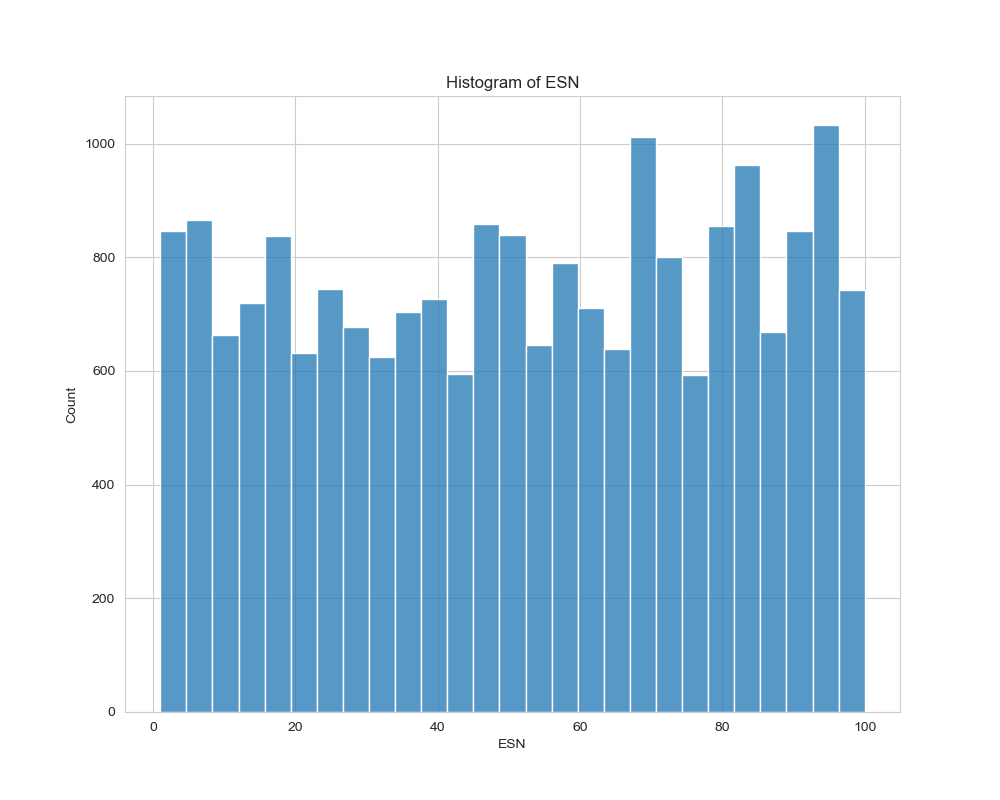

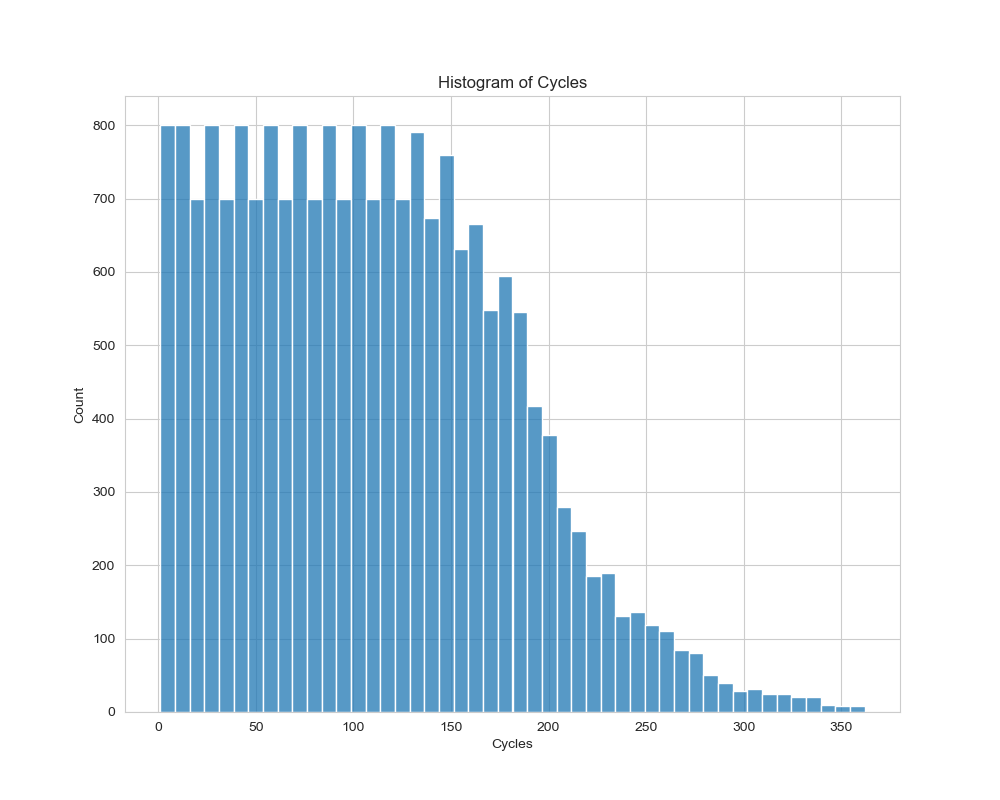

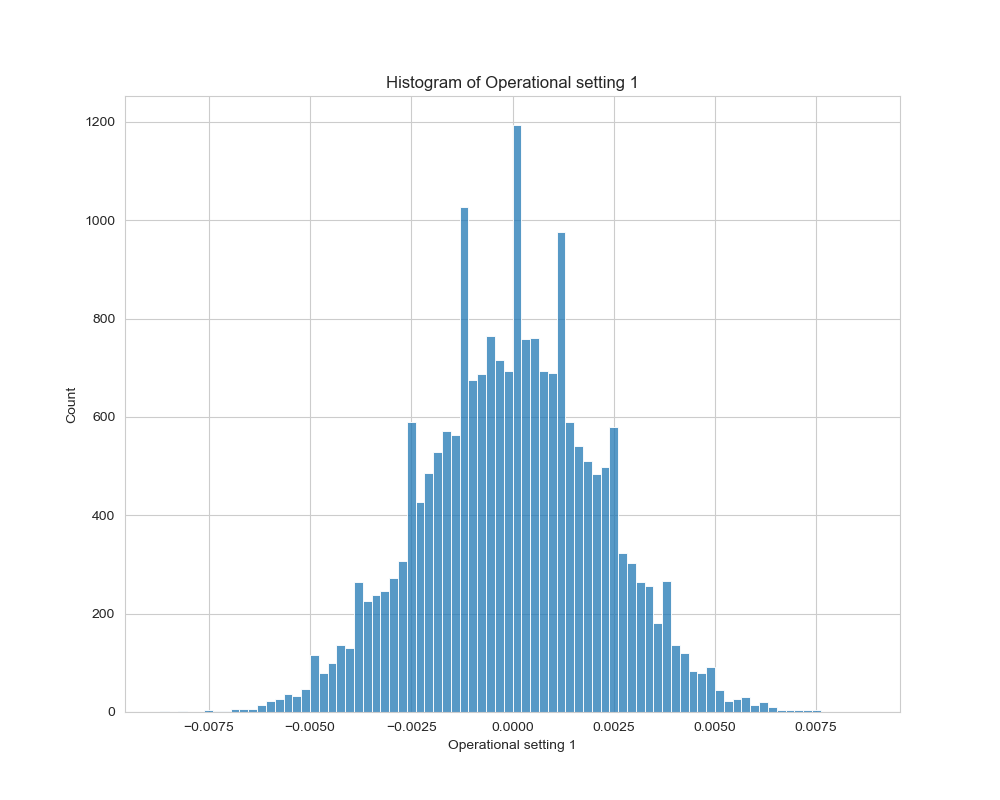

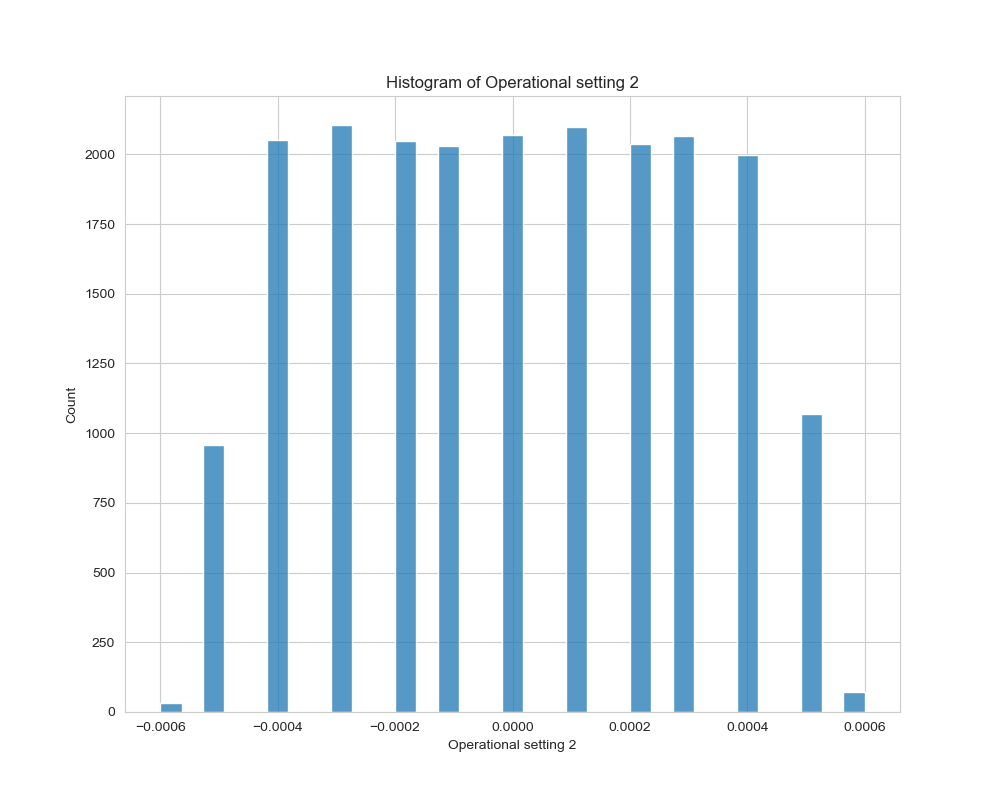

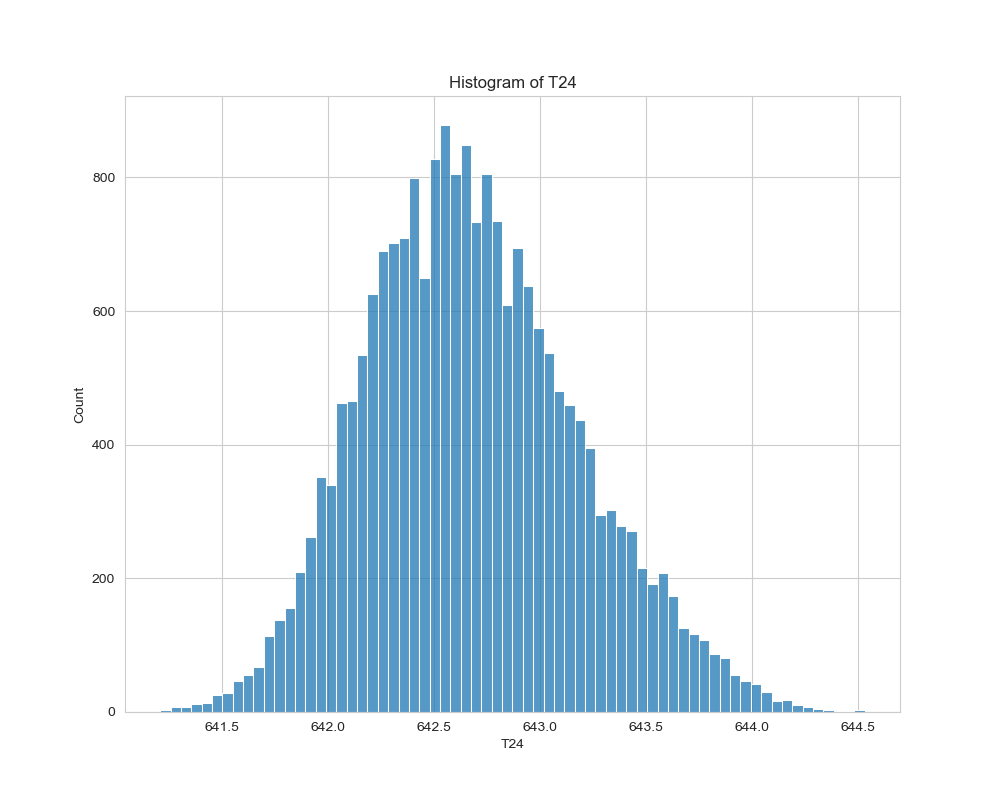

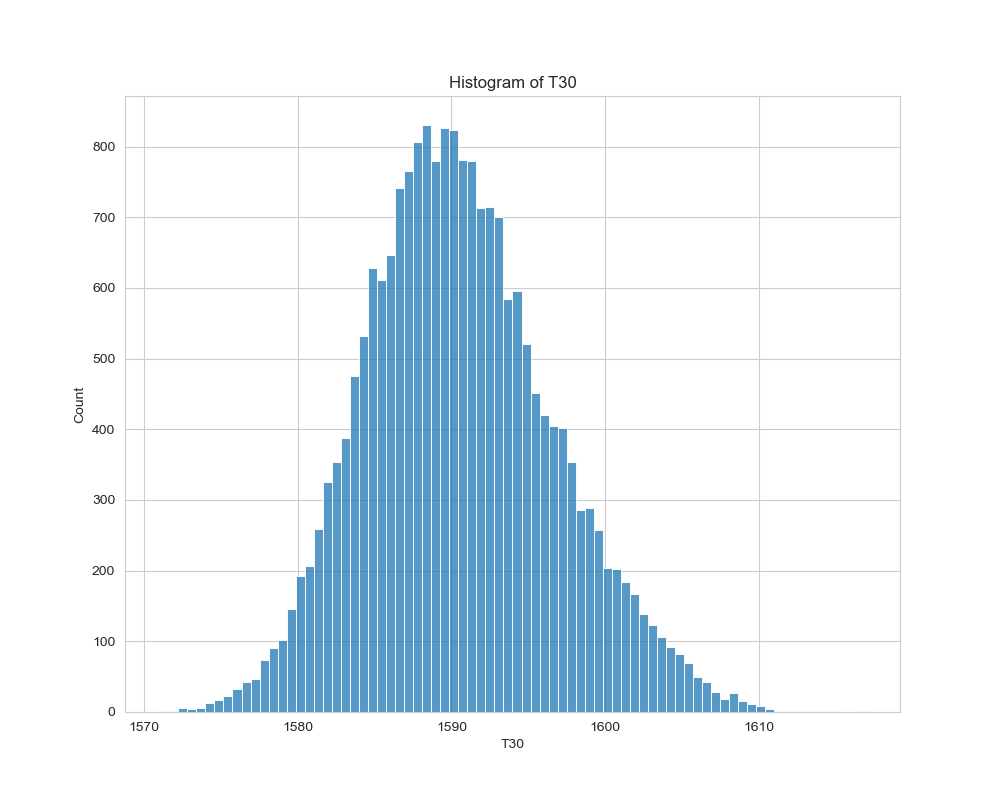

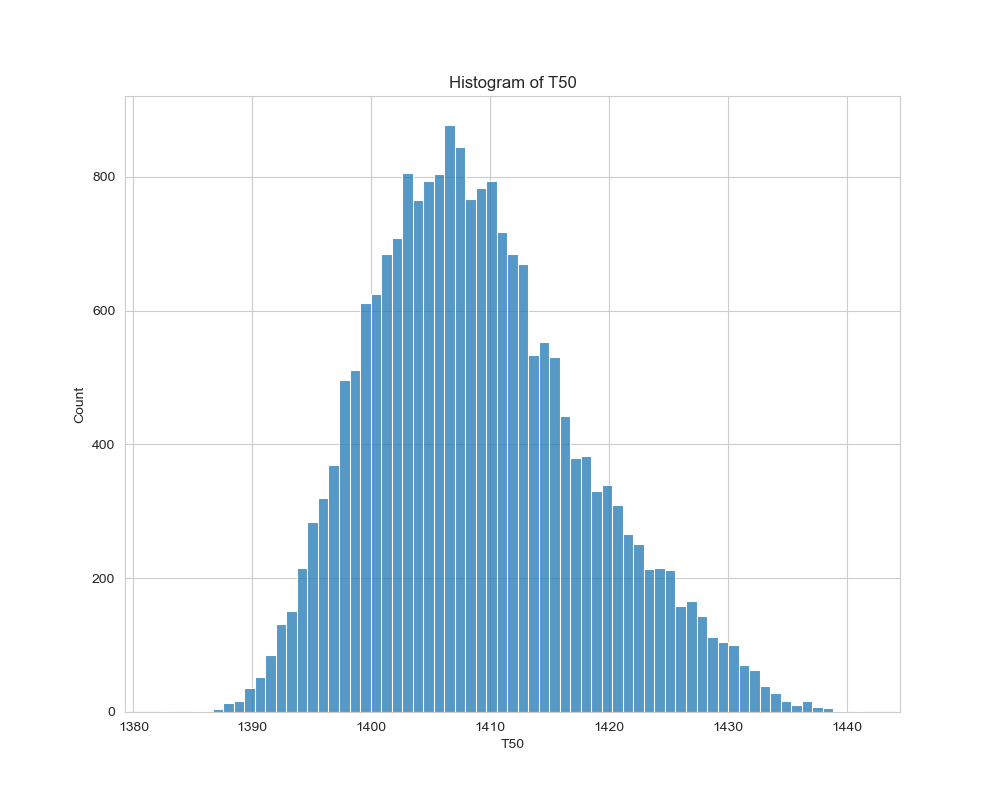

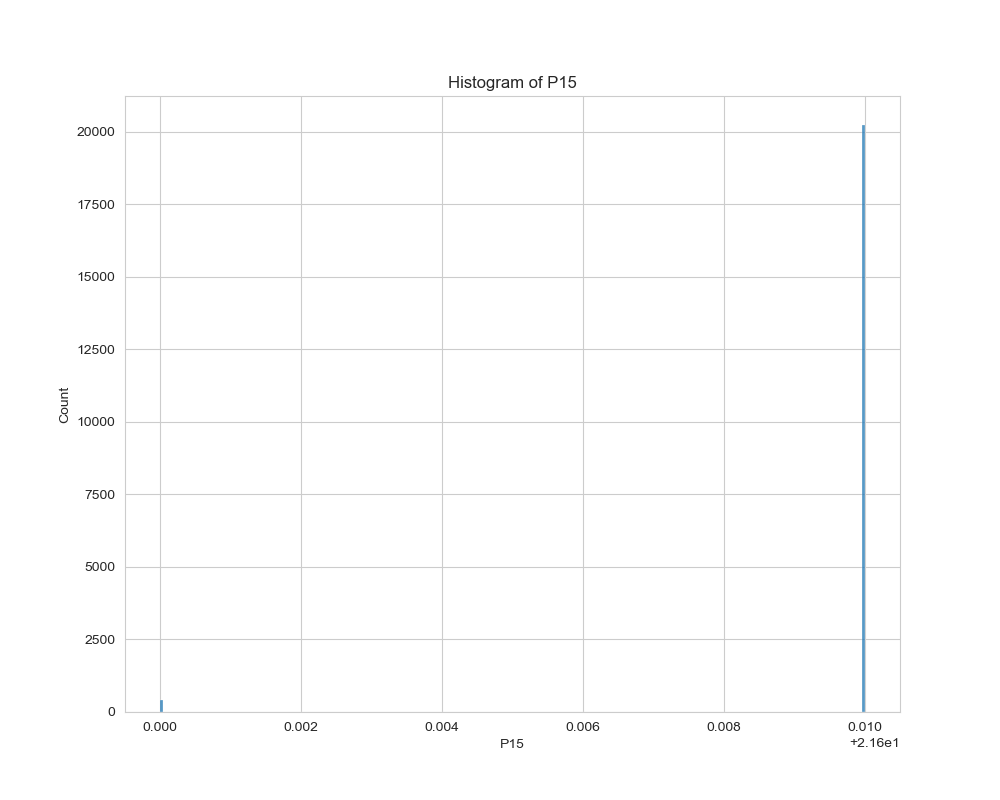

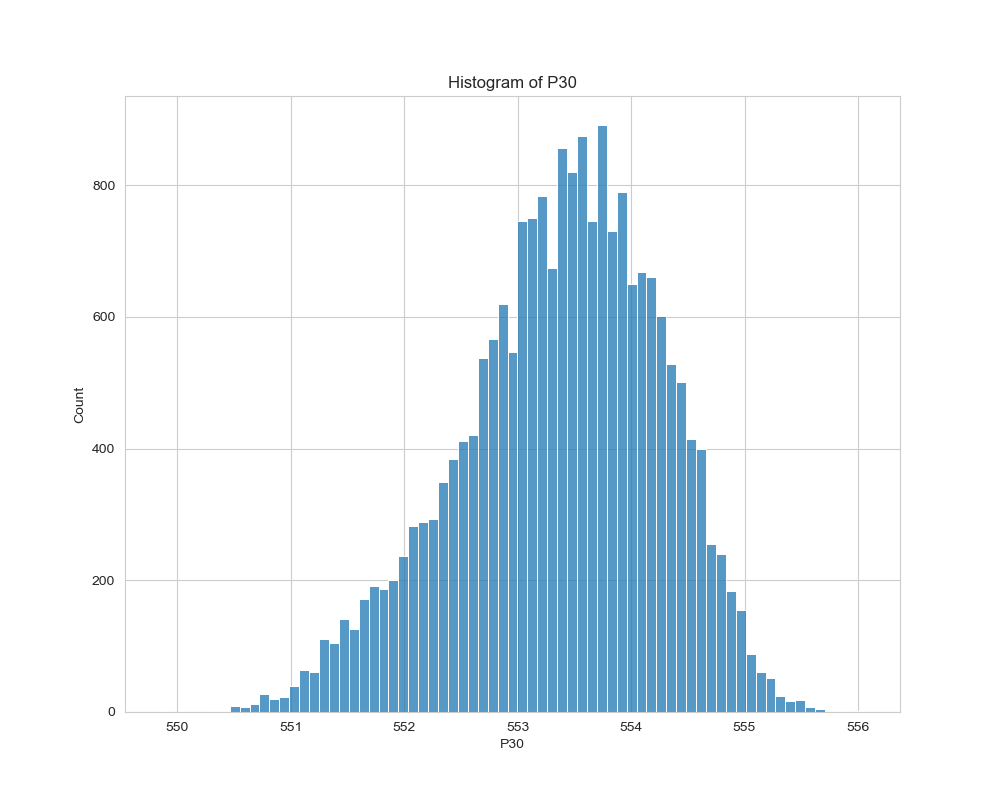

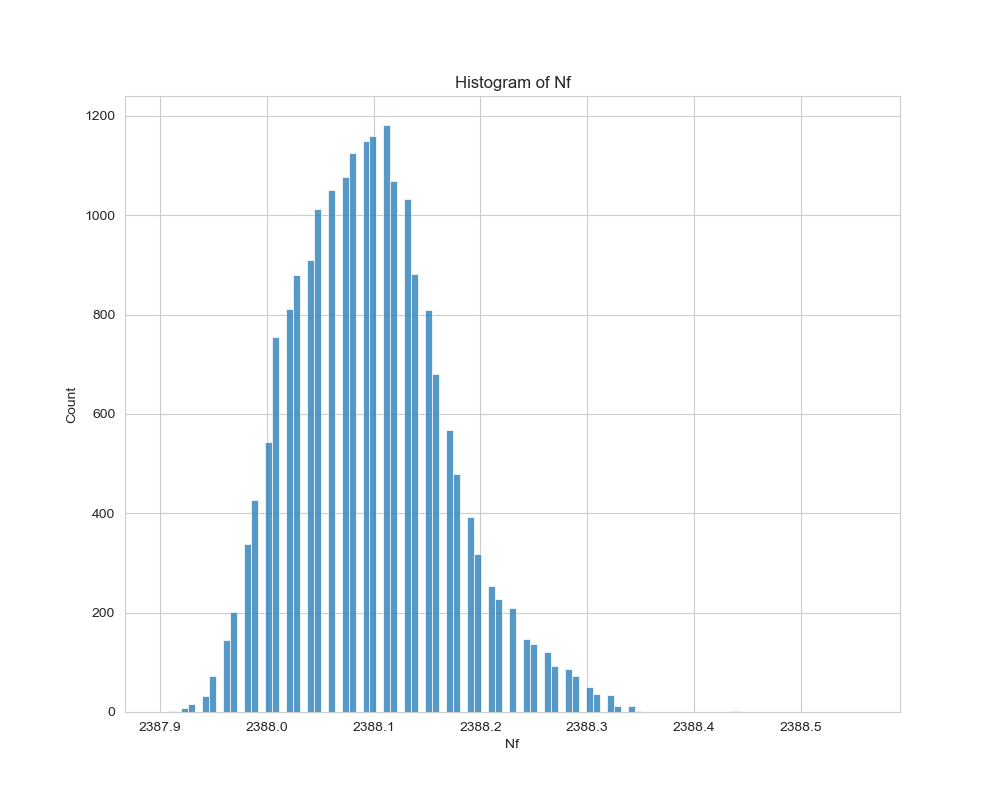

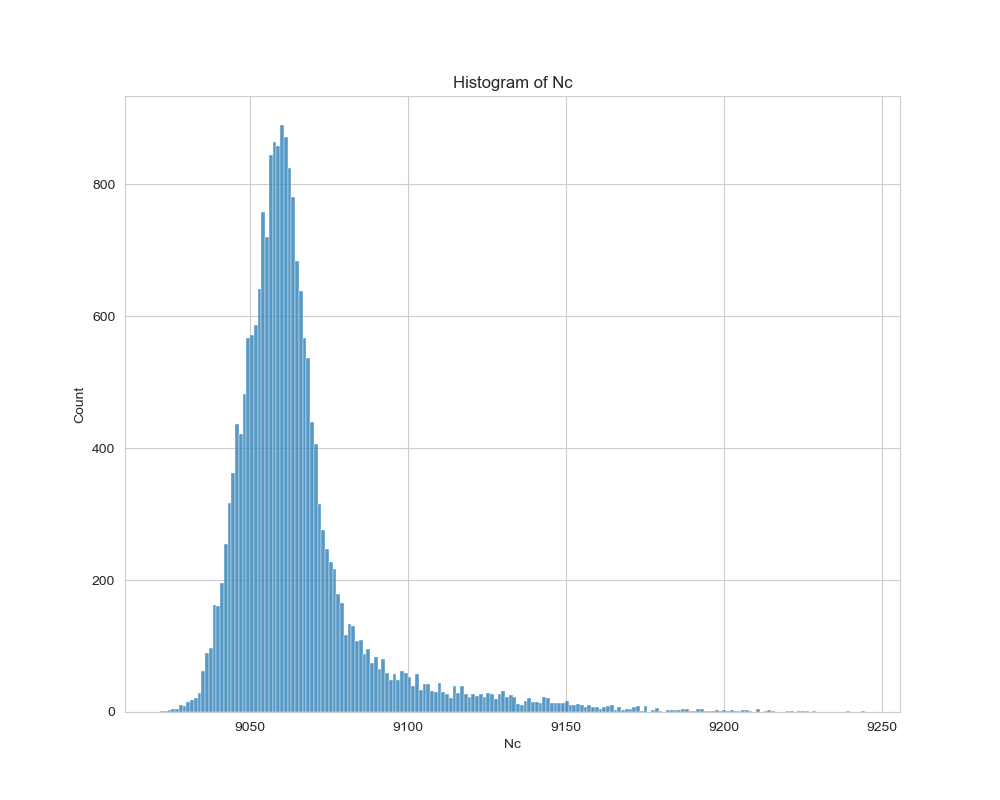

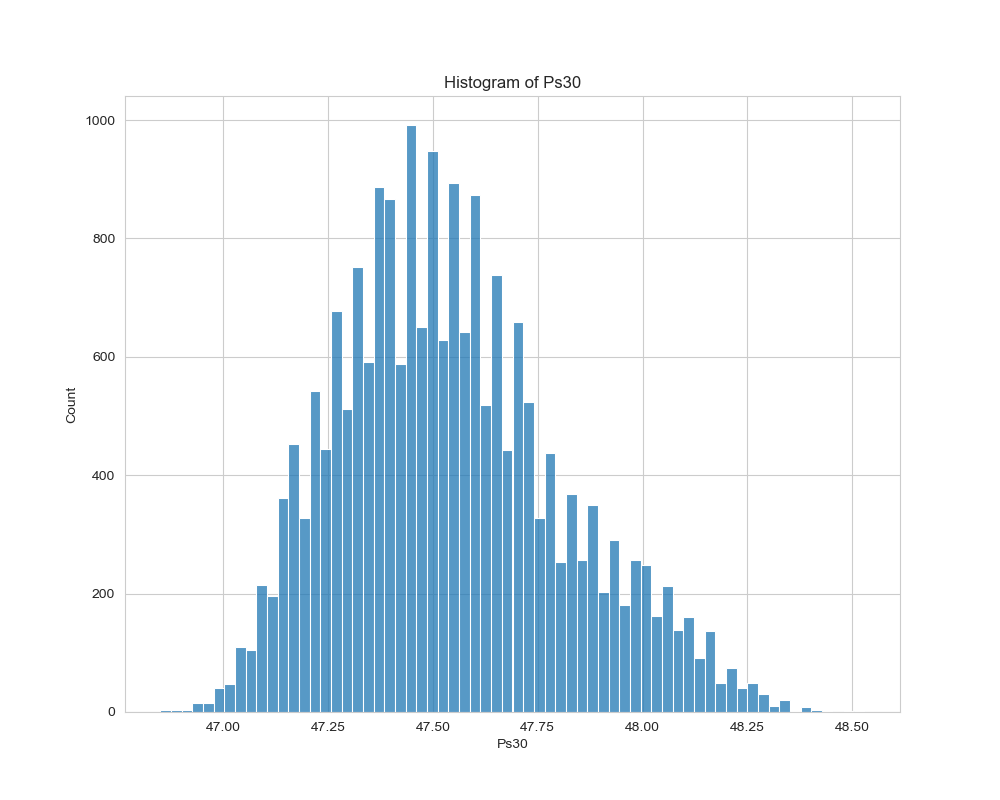

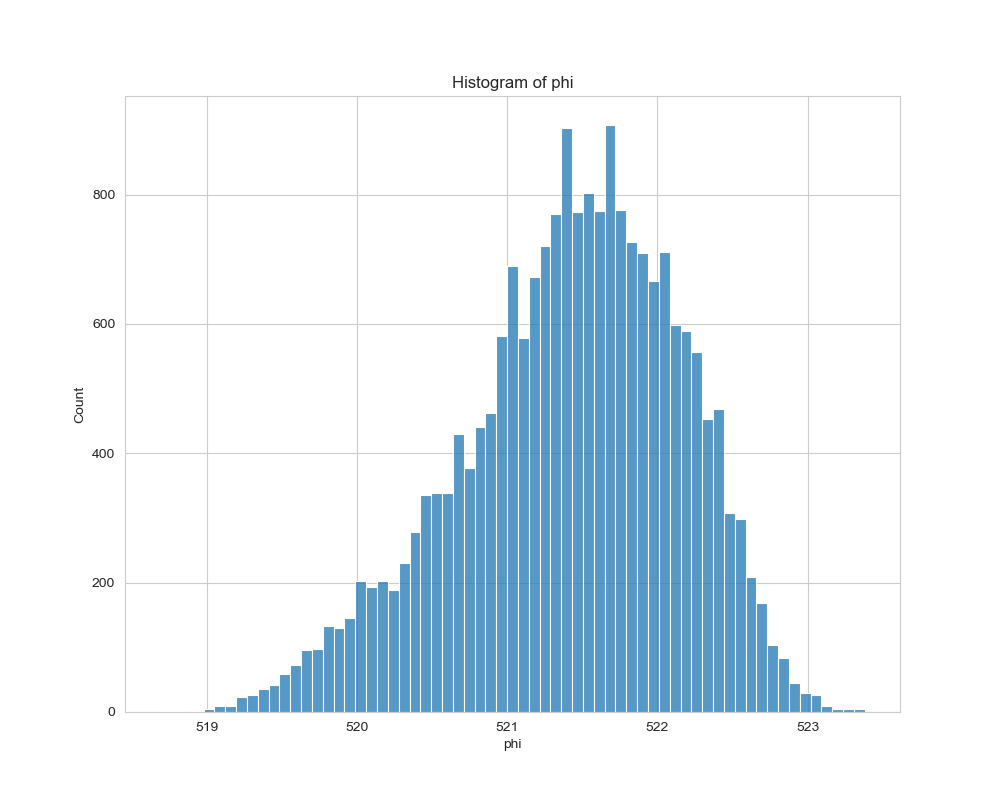

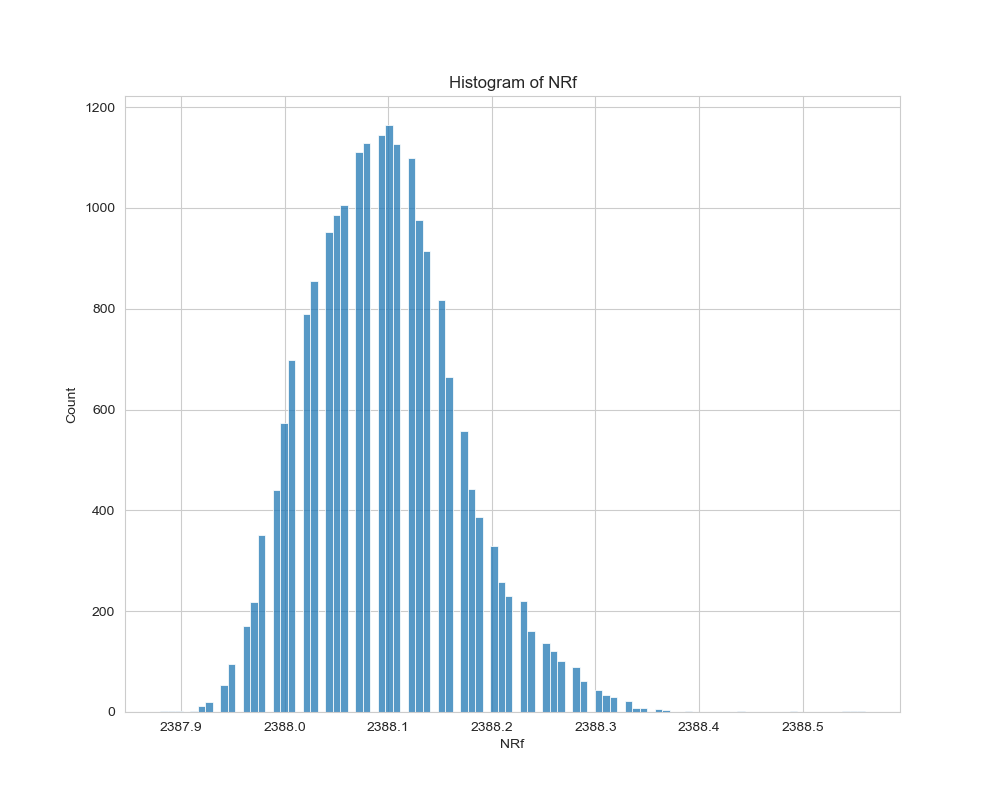

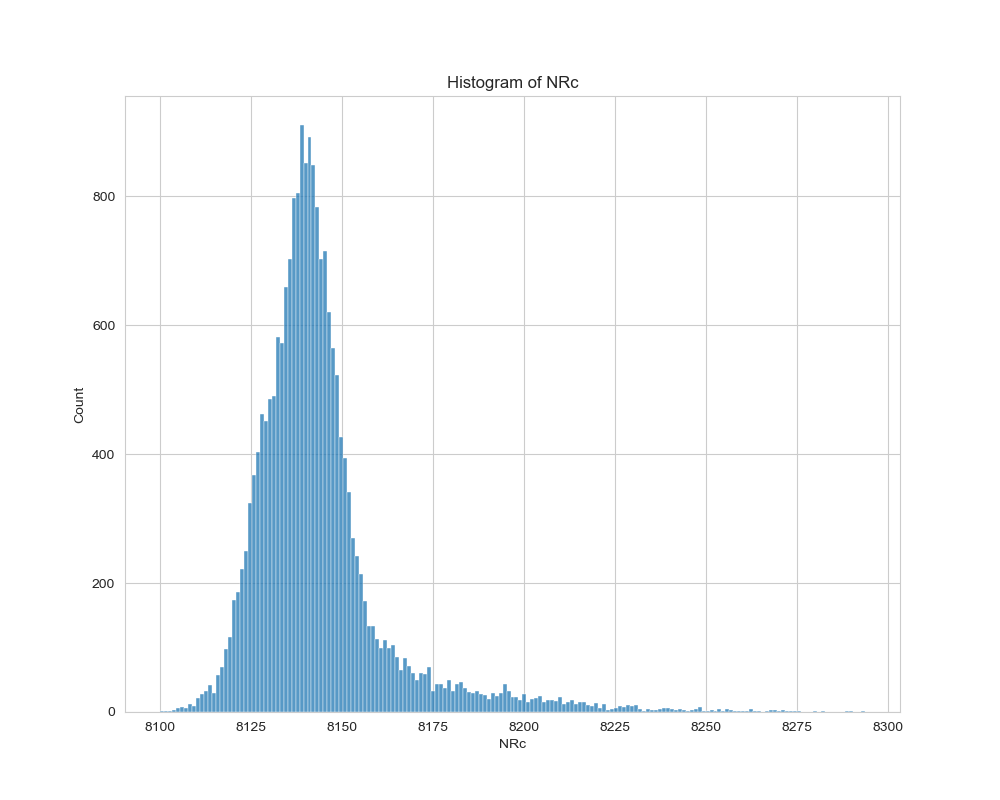

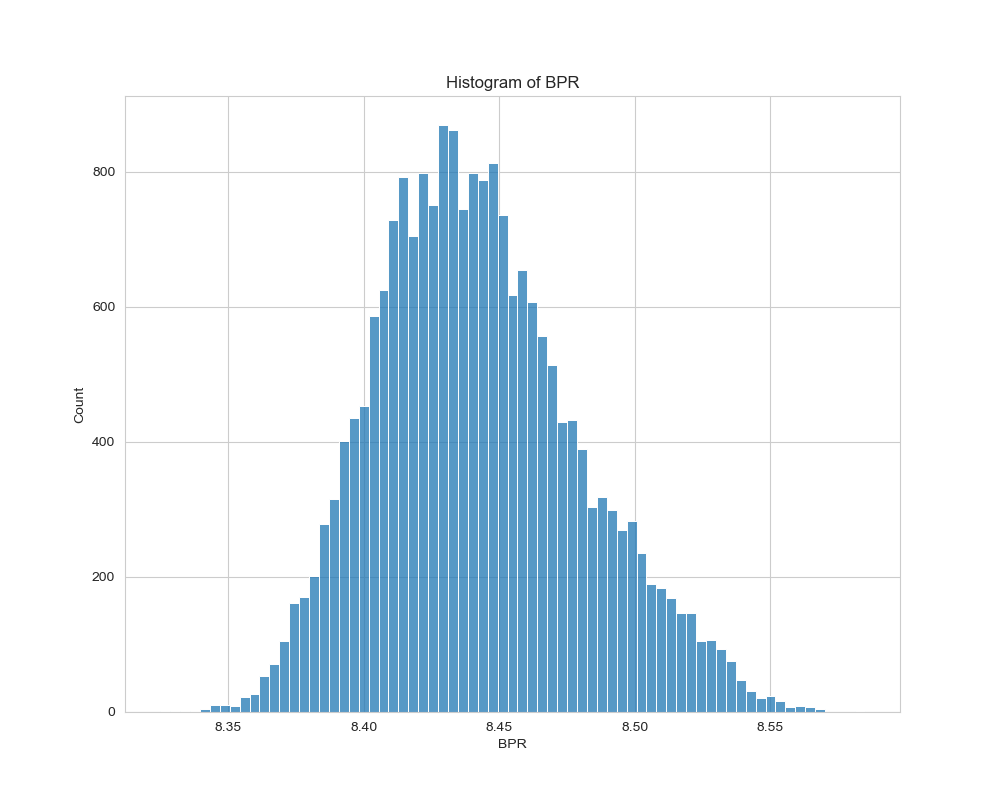

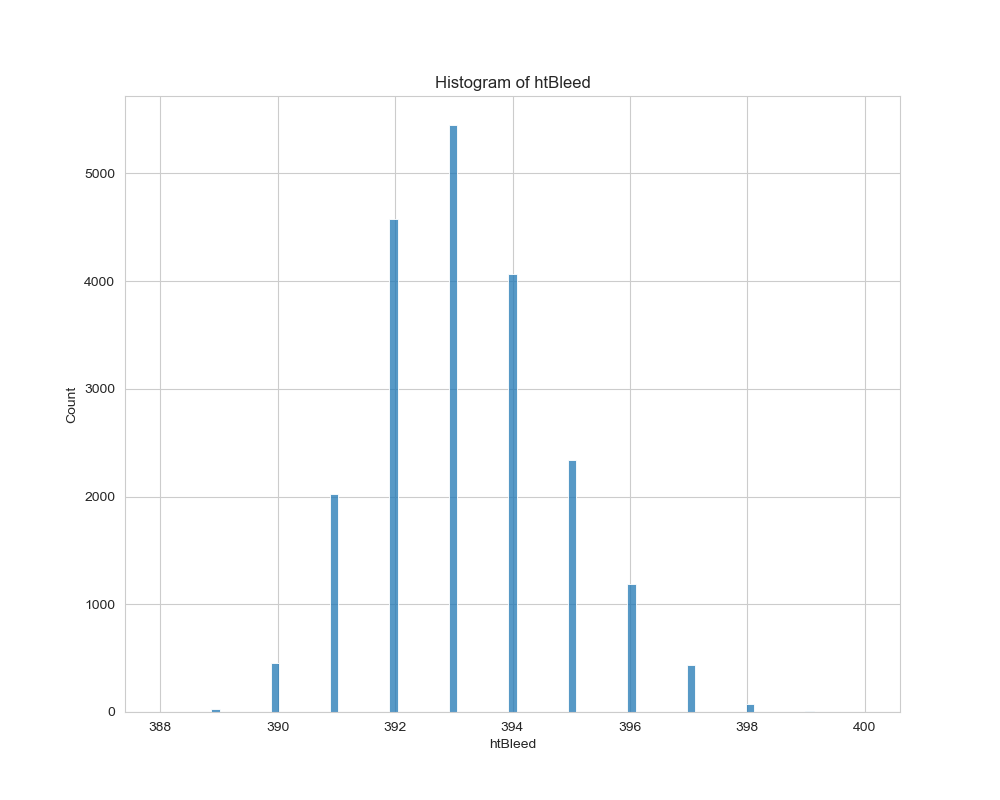

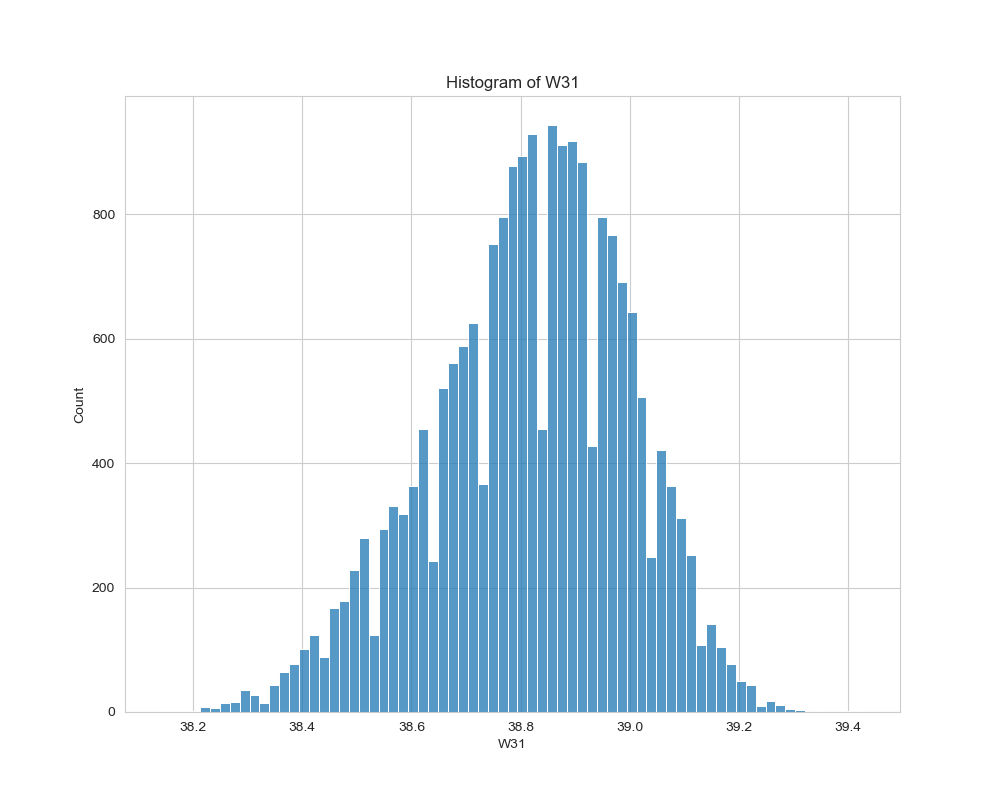

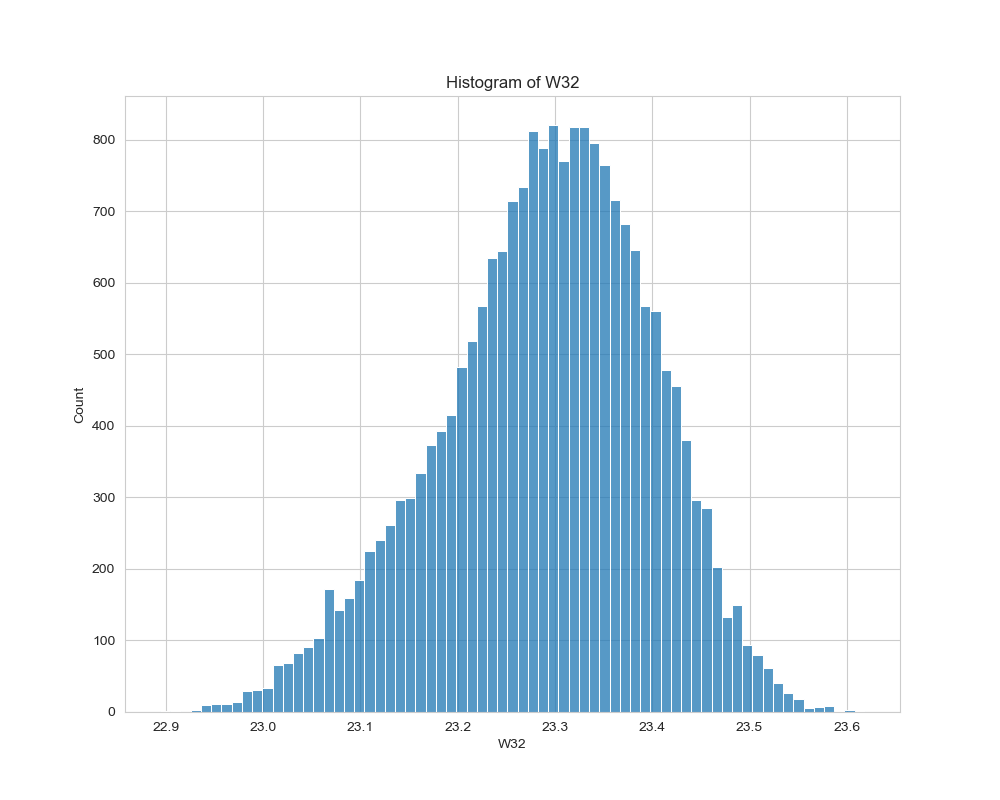

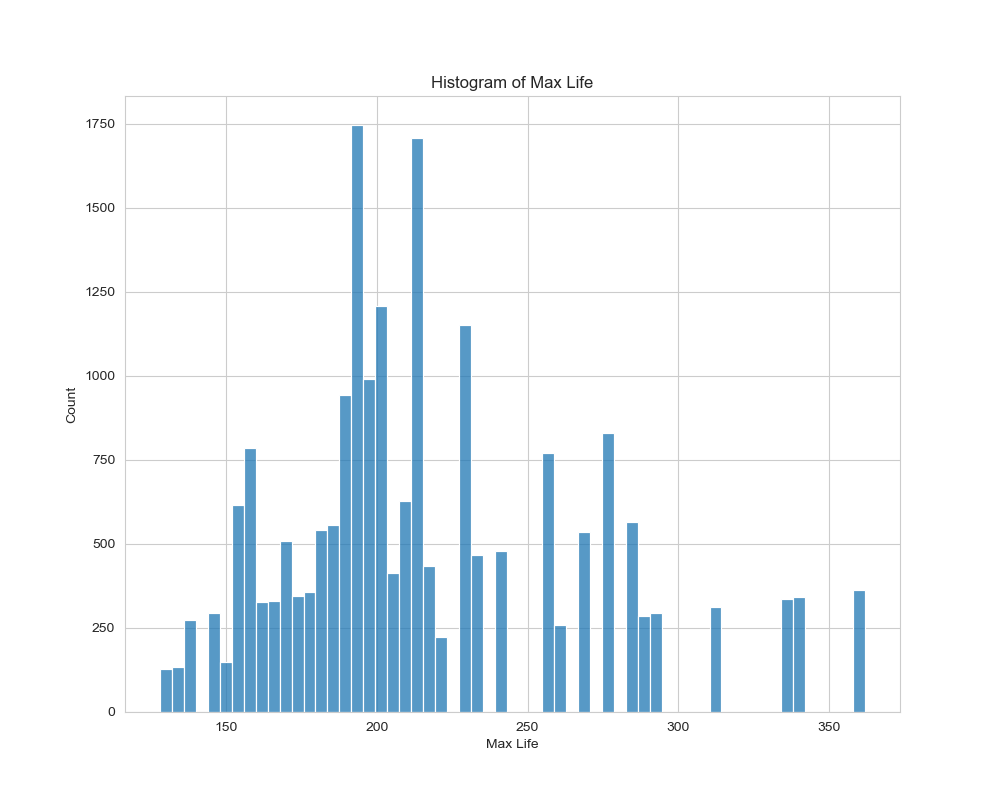

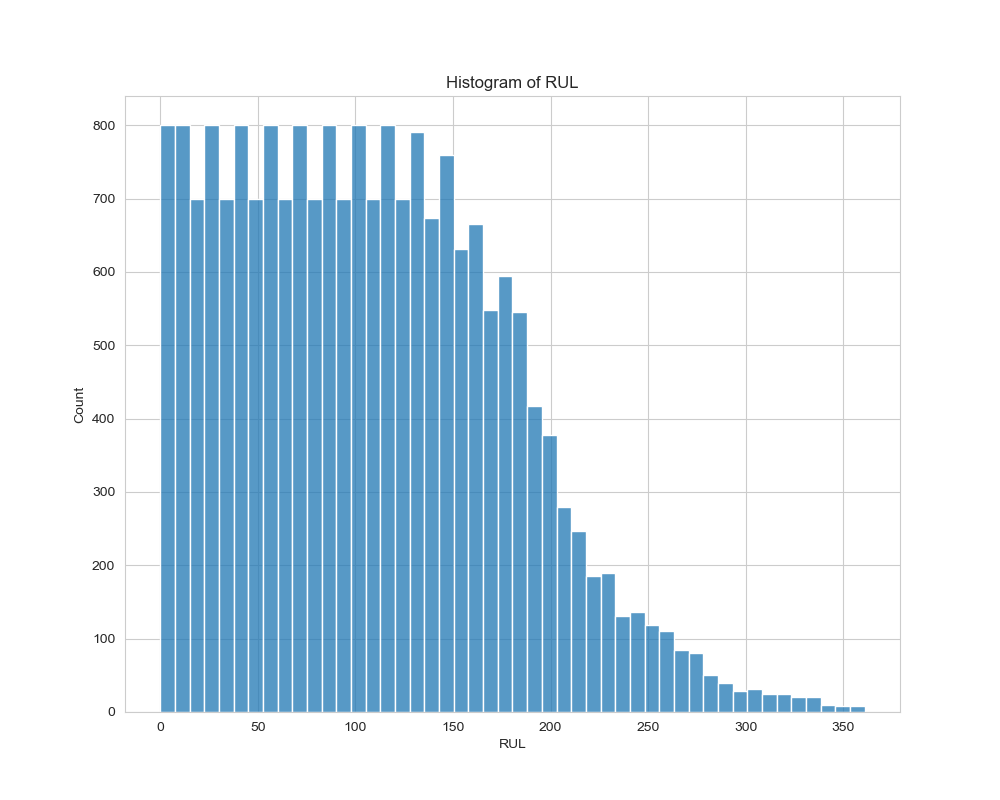

In [5]:
for col in df.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.histplot(data=df,x=col,ax=ax)
    plt.title(f'Histogram of {col}')
    fig.savefig(f'{filepath}/Output/Histograms/{col}_histogram.png')
    

## Max life histogram

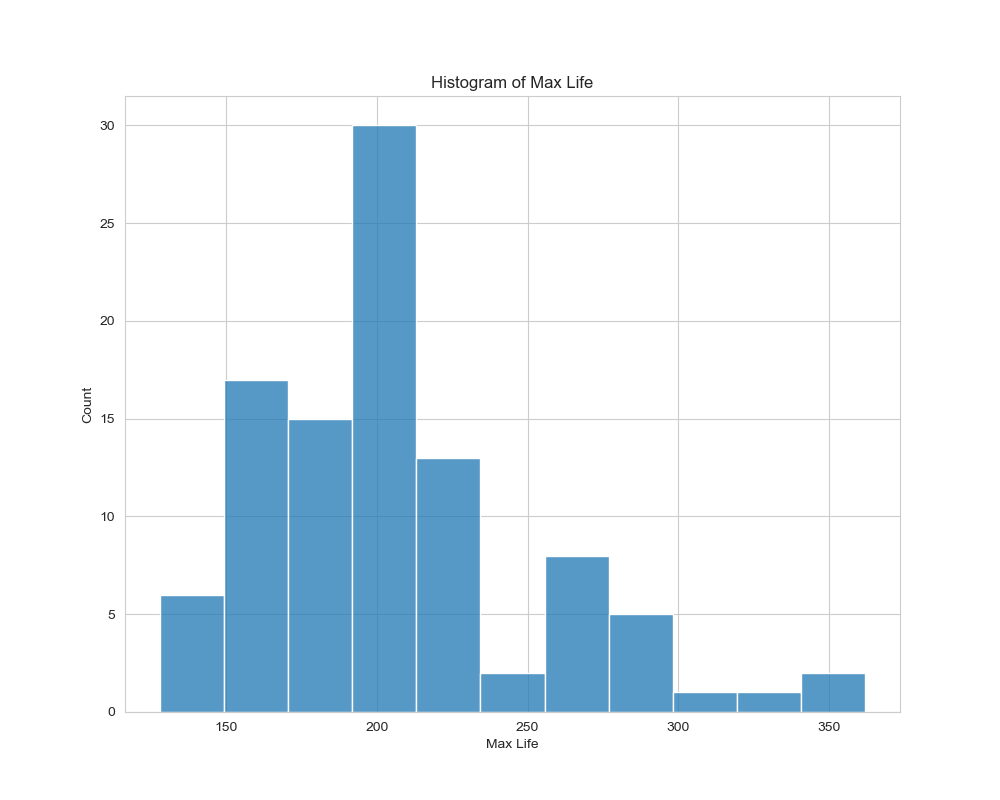

In [6]:
df_maxlife = df.drop_duplicates(subset=['ESN'],keep='last')
fig, ax = plt.subplots(figsize=(10, 8))
sns.histplot(data=df_maxlife,x='Max Life',ax=ax)
plt.title('Histogram of Max Life')
fig.savefig(f'{filepath}/Output/Histograms/Max Life_histogram.png')


# Scatterplots of highly correlated features

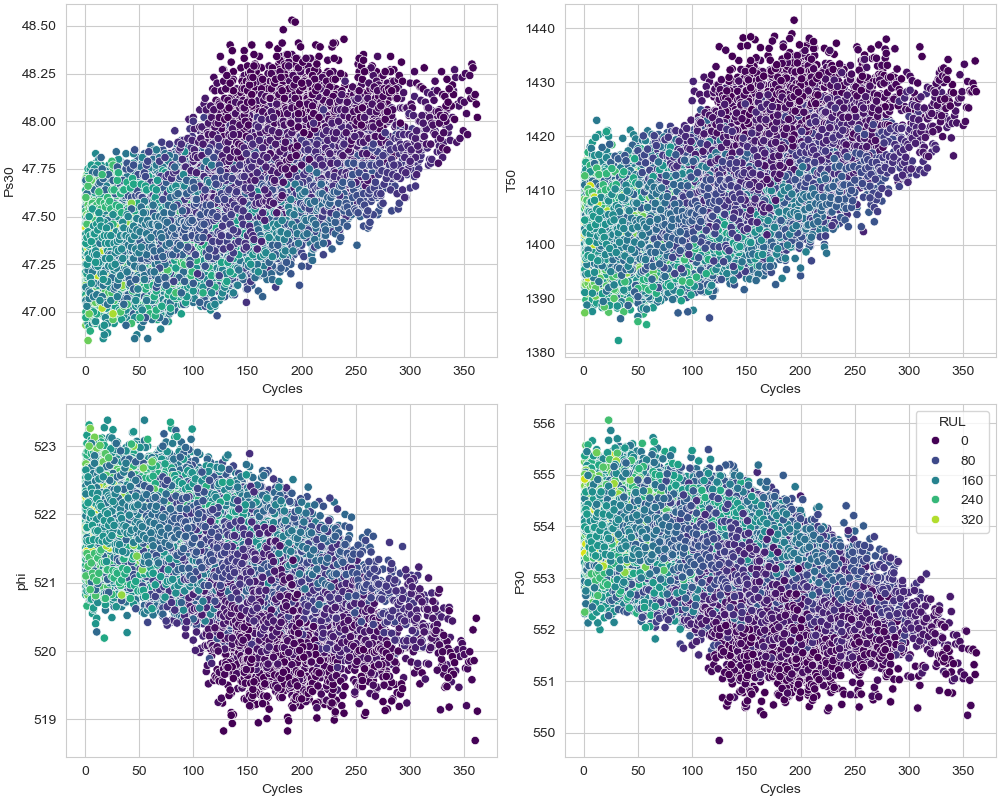

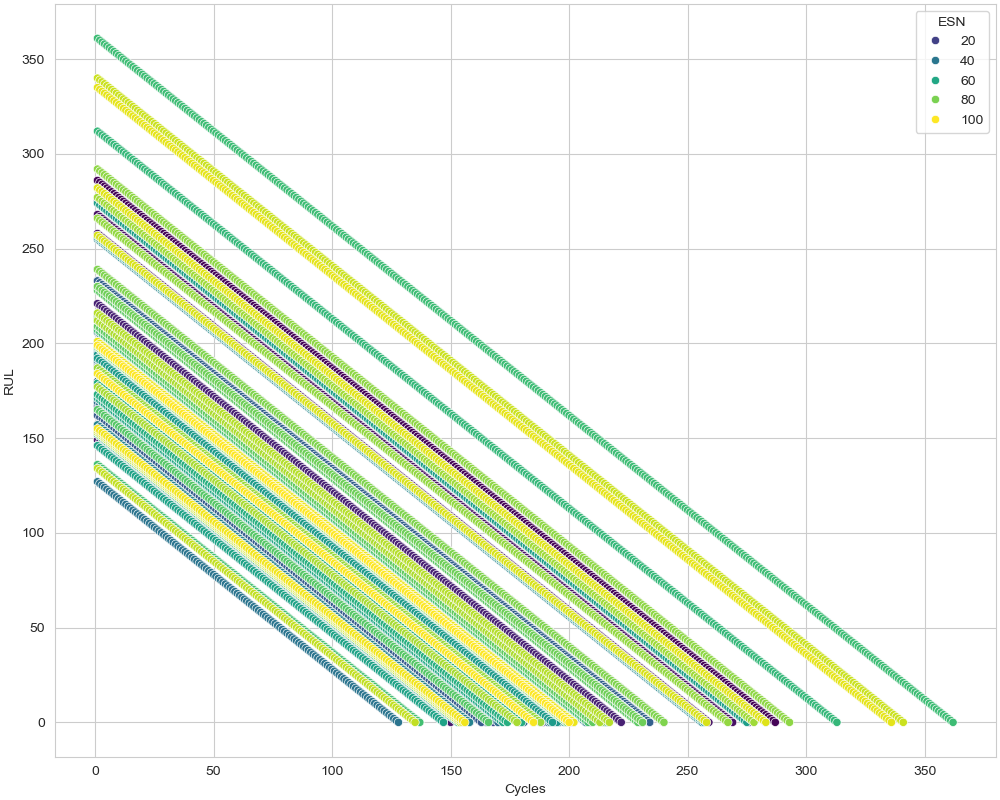

In [12]:
most_correlated = pearson['RUL'].abs().sort_values(ascending=False)[1:5].index.tolist()
most_correlated
fig, axes = plt.subplots(2, 2, figsize=(10, 8),layout='constrained')

axes = axes.ravel()   # albo: axes.flatten()

for col,ax in zip(most_correlated,axes):
    sns.scatterplot(data=df, x='Cycles', y=col, ax=ax,hue='RUL',palette='viridis',legend=False)
 #   ax.set_title(f'Scatter plot of Cycles vs {col}')
sns.scatterplot(data=df, x='Cycles', y=col, ax=ax,hue='RUL',palette='viridis',legend=True)
#fig.suptitle('Scatter plots of Cycles vs Most Correlated Features')
fig.savefig(f'{filepath}/Output/Scatterplots/RUL_vs_{col}_scatterplot.png')



fig, axes = plt.subplots(figsize=(10, 8),layout='constrained')
sns.scatterplot(data=df, x='Cycles', y='RUL', ax=axes,hue='ESN',palette='viridis',legend=True)
#fig.suptitle('Scatter plots of Cycles vs Most Correlated Features')
fig.savefig(f'{filepath}/Output/Scatterplots/RUL_vs_cycles_scatterplot.png')


# Boxplot

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\mathi\\OneDrive\\Documents\\Studia\\SGH\\Semestr 4\\Praca dyplomowa/Output/Boxplots/Boxplot.png'

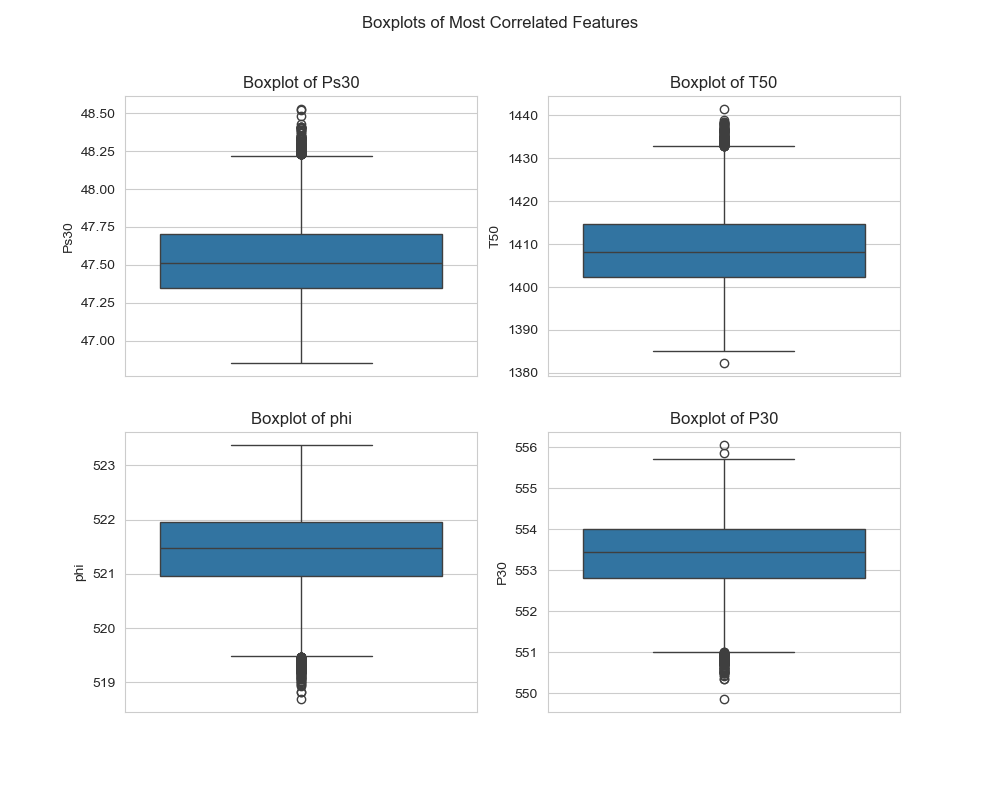

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes = axes.ravel()   # albo: axes.flatten()

for col,ax in zip(most_correlated,axes):
    sns.boxplot(data=df, y=col, ax=ax)
    ax.set_title(f'Boxplot of {col}')

fig.suptitle('Boxplots of Most Correlated Features')
fig.savefig(f'{filepath}/Output/Boxplots/Boxplot.png')


# Pairplot of most correlated features

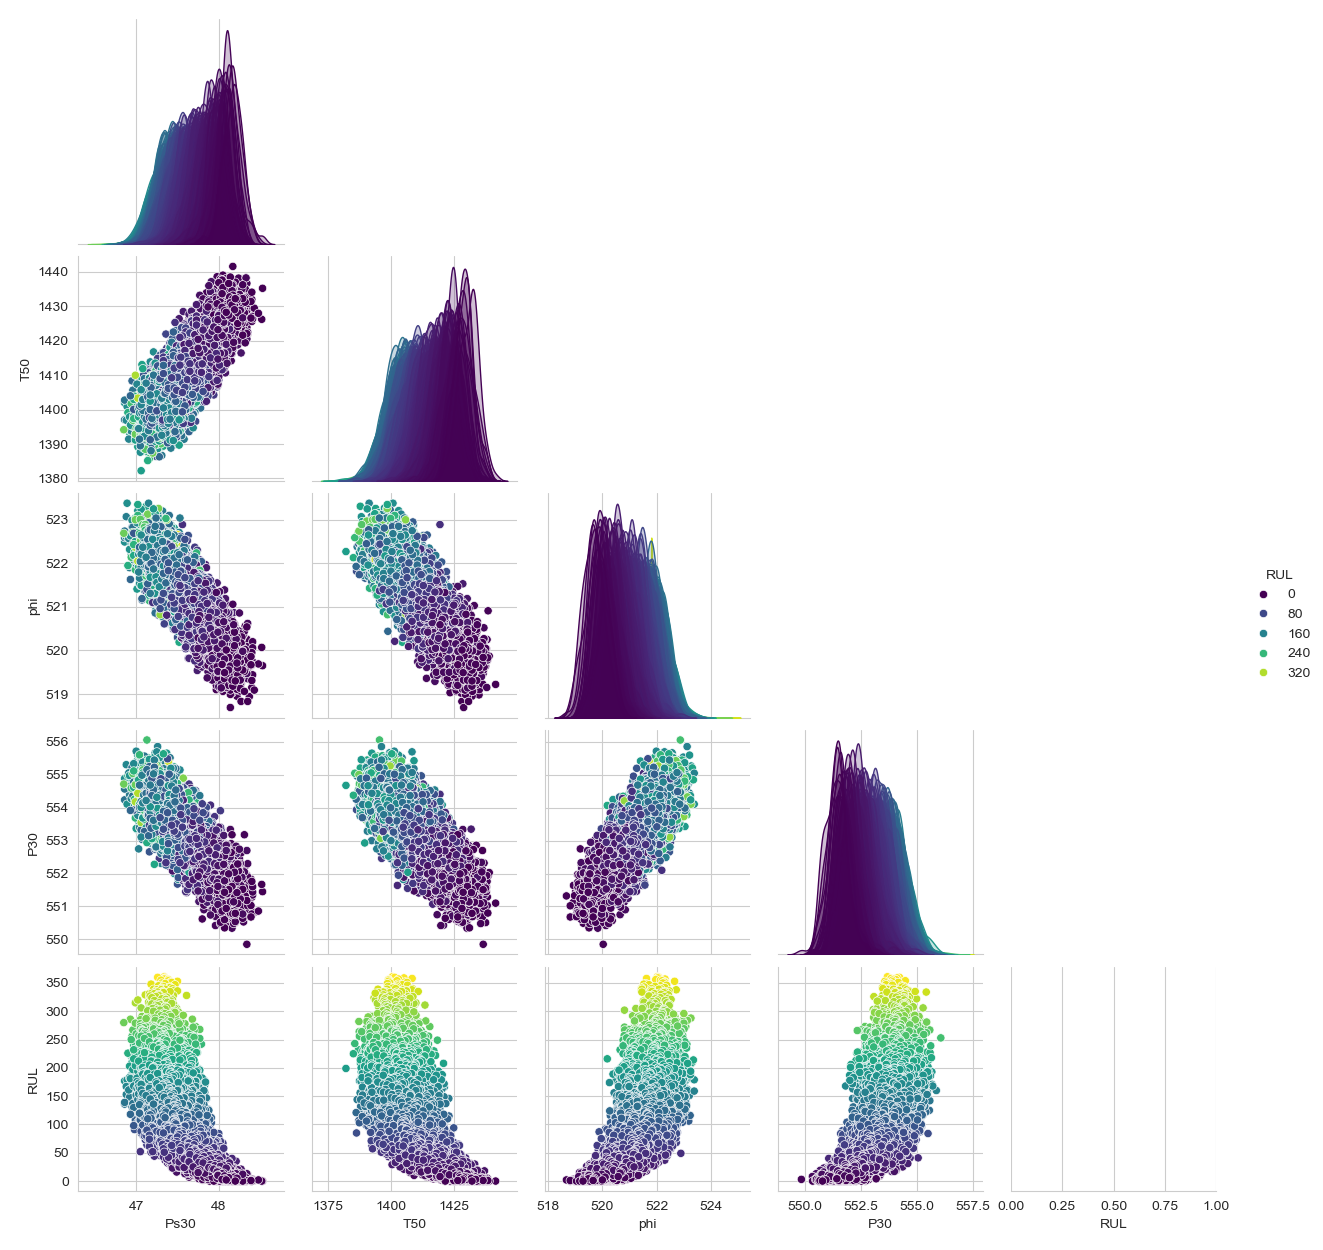

In [ ]:
#fig, axes = plt.subplots(figsize=(10, 8))

sns.pairplot(data=df, vars=most_correlated+['RUL'],
             hue='RUL', palette='viridis',
             corner=True
             )

#fig.suptitle('Boxplots of Most Correlated Features')
#fig.savefig(f'{filepath}/Output/Boxplots/Boxplot.png')
